(250, 6)
count      250.000000
mean      3600.540000
std       2652.457475
min        298.000000
25%       1082.000000
50%       3383.000000
75%       5009.250000
max      16171.000000
Name: Content, dtype: float64
count                                                   250
unique                                                  176
top       House of Representatives,Sara Duterte,Senate o...
freq                                                     18
Name: Related Topics, dtype: object
Content
MAYNILA, Pilipinas — Pinangunahan ni Father Robert Reyes, isang aktibistang pari, ang isang penitential service para sa “tunay na pagbabago” sa Korte Suprema at Senado. Ipinagdasal nila ang mga senador at mahistrado na pumigil sa impeachment ni Vice President Sara Duterte. Pagkatapos ng ilang oras, sinundan ito ng isang overnight prayer vigil sa EDSA Shrine. Panoorin ang ulat ni Paterno Esmaquel II. – Rappler.com How does this make you feel?                                                        

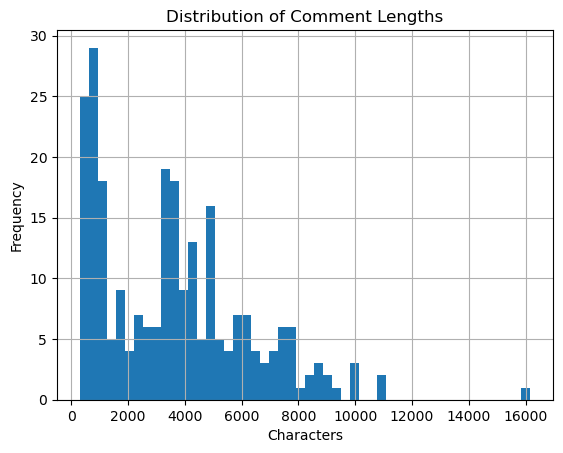

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/julyanna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic 0:
['kung', 'ito', 'ni', 'hindi', 'ay', 'mga', 'na', 'ng', 'ang', 'sa']
---
Topic 1:
['constitution', 'dutertes', 'vice', 'house', 'public', 'trial', 'said', 'senate', 'court', 'duterte']
---
Topic 2:
['articles', 'supreme', 'vice', 'case', 'duterte', 'said', 'trial', 'house', 'court', 'senate']
---
Topic 3:
['house', 'villar', 'trial', 'senators', 'said', 'candidates', 'political', 'marcos', 'vice', 'duterte']
---
Topic 4:
['said', 'senators', 'th', 'political', 'duterte', 'public', 'congress', 'trial', 'escudero', 'senate']
---


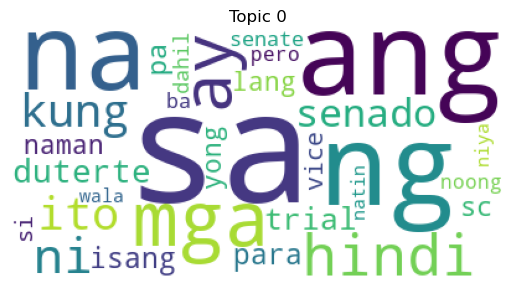

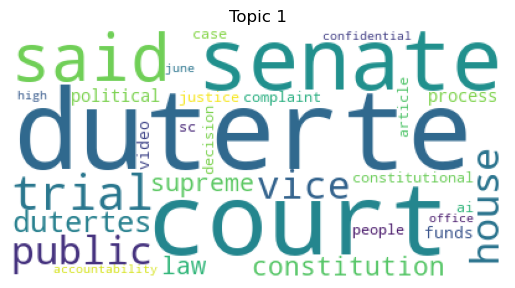

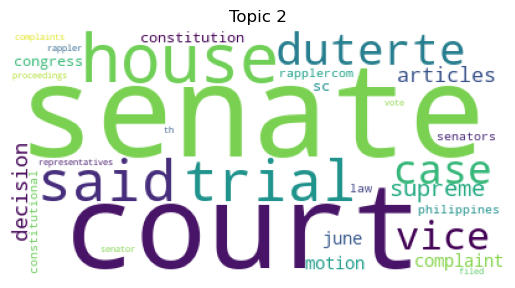

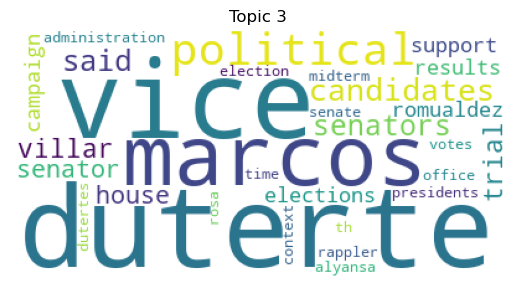

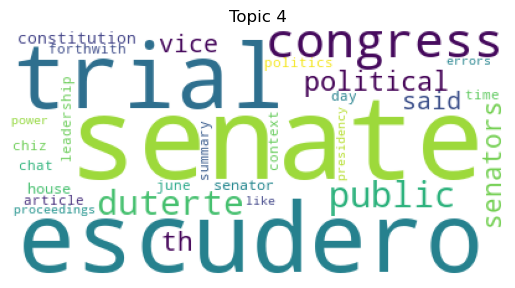

In [4]:
# Load Data
import pandas as pd

# base sheet of scraped comments
comments = pd.read_excel("rappler.xlsx")
print(comments.shape)
comments.head()

# Exploratory Data Analysis
# basic stats
print(comments['Content'].str.len().describe())
print(comments['Related Topics'].describe())

# Most common comments
print(comments['Content'].value_counts().head(10))

# distribution of comment lengths
import matplotlib.pyplot as plt
comments['Content'].str.len().hist(bins=50)
plt.title("Distribution of Comment Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

# nlp Preprocessing
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+', '', text)      # remove links
    text = re.sub(r'[^a-z\s]', '', text)     # keep only letters
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

comments['processed_text'] = comments['Content'].apply(clean_text)
comments[['Content','processed_text']].head()

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# vectorize
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')
X = vectorizer.fit_transform(comments['processed_text'])

# fit LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

# print top words per topic
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx}:")
    print([terms[i] for i in topic.argsort()[-10:]])
    print("---")

# visualize topics with word clouds
from wordcloud import WordCloud

for idx, topic in enumerate(lda.components_):
    plt.figure()
    plt.imshow(WordCloud(background_color='white').fit_words({terms[i]: topic[i] for i in topic.argsort()[-30:]}))
    plt.axis("off")
    plt.title(f"Topic {idx}")
    plt.show()

# Assign Topics to Comments
comment_topics = lda.transform(X).argmax(axis=1)
comments['topic'] = comment_topics
comments[['Content','topic']].head(20)

# Save results
comments.to_excel("rappler_with_comments.xlsx")

## Exploratory data Analysis
- Number of comments: 3043
- distribution of lengths is skewed (most under 200 characters)
- Most common words include political names (Risa (hontiveros), Raffy (tulfo), etc.)

## Topic Modeling Results
- Topic 0: Support for Risa Hontiveros
- Topic 1: Criticism & comparisons with other senators
- Topic 2: Conversational fillers in tagalog
- Topic 3: political commentary in general
- Topic 4: Mentions of senators (Chiz, Marcoleta, etc.)


In [2]:
import os
os.path.exists("youtube_comments_with_topics.xlsx")

True